This notebook summarizes the streamflow information and attempts to define flooding severity for each gauge.

In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wandb
import numpy as np
import os
import gc

In [2]:
# Set global row display limit for Polars DataFrames
pl.Config.set_tbl_rows(20)

polars.config.Config

In [3]:
# Connect to Weights and Biases API
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\mroth\.netrc.


In [4]:
# Load the raw streamflow dataset from wandb
artifact = api.artifact("flood-forecasting/raw-streamflow-daily:latest")
artifact_dir = artifact.download()

# Read the parquet file
sfd_df = pl.read_parquet(os.path.join(artifact_dir, "streamflow_daily", "streamflow_daily.parquet"))

wandb:   1 of 1 files downloaded.  


In [5]:
print(f"Full dataset: {sfd_df.shape[0]:,} rows x {sfd_df.shape[1]} columns")
print(f"Total sites: {sfd_df['site_id'].n_unique()}")
print(sfd_df.head())
print(f"Date range: {sfd_df['date'].min()} to {sfd_df['date'].max()}")

size_mb = sfd_df.estimated_size("mb")
print(f"{size_mb:.2f} MB")

Full dataset: 5,015,435 rows x 6 columns
Total sites: 1049
shape: (5, 6)
┌──────────┬──────────────┬───────────────────┬───────────────────┬────────────┬───────────────────┐
│ site_id  ┆ date         ┆ streamflow_cfs_me ┆ gage_height_ft_me ┆ qualifiers ┆ extracted_at      │
│ ---      ┆ ---          ┆ an                ┆ an                ┆ ---        ┆ ---               │
│ str      ┆ datetime[μs, ┆ ---               ┆ ---               ┆ str        ┆ datetime[μs]      │
│          ┆ UTC]         ┆ f64               ┆ f64               ┆            ┆                   │
╞══════════╪══════════════╪═══════════════════╪═══════════════════╪════════════╪═══════════════════╡
│ 06052500 ┆ 2007-10-01   ┆ 490.0             ┆ null              ┆ A          ┆ 2026-02-01        │
│          ┆ 00:00:00 UTC ┆                   ┆                   ┆            ┆ 11:59:31.672138   │
│ 06052500 ┆ 2007-10-02   ┆ 512.0             ┆ null              ┆ A          ┆ 2026-02-01        │
│          ┆ 00:00

In [6]:

# Create basic statistics per site 

site_stats = (
    sfd_df
    .filter(pl.col("streamflow_cfs_mean").is_not_null())
    .group_by("site_id")
    .agg([
        pl.col("streamflow_cfs_mean").mean().round(1).alias("mean_cfs"),
        pl.col("streamflow_cfs_mean").max().alias("max_cfs"),
        pl.col("streamflow_cfs_mean").median().alias("median_cfs"),
        pl.col("streamflow_cfs_mean").count().alias("n_observations")
    ])
    .sort("max_cfs", descending=True)
)

print("Site-level statistics:")
print(site_stats.shape)

Site-level statistics:
(1003, 5)


In [7]:
# Create basic statistics per site through function
def compute_site_stats(df, site_id_col, streamflow_col):
    return (
        df
        .filter(pl.col(streamflow_col).is_not_null())
        .group_by(site_id_col)
        .agg([
            pl.col(streamflow_col).mean().round(1).alias("mean_cfs"),
            pl.col(streamflow_col).max().alias("max_cfs"),
            pl.col(streamflow_col).median().alias("median_cfs"),
            pl.col(streamflow_col).count().alias("n_observations")
        ])
        .sort("max_cfs", descending=True)
    )

In [8]:
site_stats = compute_site_stats(sfd_df, "site_id", "streamflow_cfs_mean")

print("Site-level statistics:")
print(site_stats.shape)

Site-level statistics:
(1003, 5)


The catchment attributes table does not contain data on all sites. Therefore we must use it as a filter.

In [9]:
import duckdb

con = duckdb.connect("../flood_forecasting.duckdb", read_only=True)

ca_df = con.execute("SELECT * FROM main_marts.dim_catchment_attributes_full").pl()
con.close()

print(ca_df.shape)

(9008, 559)


In [10]:
count = site_stats.filter(
    pl.col("site_id").is_in(ca_df["site_id"].to_list())
).shape[0]

print(f"Number of matching site_ids: {count}")

Number of matching site_ids: 650


In [11]:
# Remove sites that are not found in the catchment attributes dataset
site_stats_filt = site_stats.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)

# Add latitude and longitude for mapping
site_stats_filt = site_stats_filt.join(
    ca_df.select([
        pl.col("site_id"),
        pl.col("LAT_GAGE").alias("latitude"),
        pl.col("LNG_GAGE").alias("longitude")
    ]),
    on="site_id",
    how="left"
)

print(site_stats_filt.shape)
# print(site_stats_filt.head(10))

(650, 7)


In [12]:
import plotly.express as px

def plot_gauge_locations(df, title_text, color_variable, colorscale_text):
    fig = px.scatter_geo(
        df,
        lat="latitude",
        lon="longitude",
        color=color_variable,
        color_continuous_scale="Viridis",
        scope="usa",
        hover_name="site_id",
        title=title_text,
        labels={color_variable: colorscale_text},
    )

    fig.update_layout(geo=dict(
        showland=True,
        showlakes=True,
        showsubunits=True,
        subunitcolor="gray"
    ))

    fig.update_layout(
        title_x=0.5,
        margin={"r": 0, "t": 30, "l": 20, "b": 0}
)


    fig.show()

In [13]:
plot_gauge_locations(site_stats_filt, "Maximum Streamflow (cfs) at USGS Gauges", "max_cfs", "Max Streamflow (cfs)")

In [14]:
# Function for creating annual peaks DataFrame for Log-Pearson Type III Distribution Fitting

def calc_annual_peaks(df, station_col,streamflow_col, date_col,):
    """
    Takes a polars Dataframe and calculates the annual discharge peaks for each station. 
    
    Inputs:
        df: Polars DataFrame containing streamflow data
        station_col: Name of the column containing station identifiers (e.g., 'site_id')
        streamflow_col: Name of the column containing streamflow values (e.g., 'streamflow_cfs_mean')
        date_col: Name of the column containing date values (e.g., 'date')
    Returns:
        New DataFrame with columns for station_id, year, peak_discharge, and peak_date.
    """
    return (
        df
        .filter(pl.col(streamflow_col).is_not_null()) 
        .filter(pl.col(streamflow_col) > 0) 
        .with_columns([
            # Calculate  year
            pl.when(pl.col(date_col).dt.month() >= 10)
            .then(pl.col(date_col).dt.year() + 1)
            .otherwise(pl.col(date_col).dt.year())
            .alias("year")
        ])
        .group_by([station_col, "year"])
        .agg([
            pl.col(streamflow_col).max().alias("peak_discharge_cfs"),
            pl.col(date_col).sort_by(streamflow_col).last().alias("peak_date")
        ])
        .sort([station_col, "year"])
    )

In [15]:
annual_peaks_sfd = calc_annual_peaks(sfd_df, "site_id", "streamflow_cfs_mean", "date")

# Remove sites that are not found in the catchment attributes dataset
annual_peaks_sfd_filt = annual_peaks_sfd.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)
print(f"Annual peaks extracted: {annual_peaks_sfd.shape[0]:,} site-years")
print(annual_peaks_sfd_filt.head())

Annual peaks extracted: 14,763 site-years
shape: (5, 4)
┌──────────┬──────┬────────────────────┬─────────────────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date               │
│ ---      ┆ ---  ┆ ---                ┆ ---                     │
│ str      ┆ i32  ┆ f64                ┆ datetime[μs, UTC]       │
╞══════════╪══════╪════════════════════╪═════════════════════════╡
│ 06006000 ┆ 2008 ┆ 146.0              ┆ 2008-06-23 00:00:00 UTC │
│ 06006000 ┆ 2009 ┆ 129.0              ┆ 2009-06-06 00:00:00 UTC │
│ 06006000 ┆ 2010 ┆ 138.0              ┆ 2010-06-05 00:00:00 UTC │
│ 06006000 ┆ 2011 ┆ 239.0              ┆ 2011-06-30 00:00:00 UTC │
│ 06006000 ┆ 2012 ┆ 146.0              ┆ 2012-06-06 00:00:00 UTC │
└──────────┴──────┴────────────────────┴─────────────────────────┘


Calculate Log-Pearson Type III Distribution Stats for Flood Measurements

In [16]:
from scipy.stats import pearson3

def calc_lp3_params(peak_df, station_col, discharge_col, min_years: int = 10, return_periods=[2, 5, 10, 25, 50, 100]):
    """
    Calculate Log-Pearson Type III flood quantiles for each station.
    
    Inputs:
        peak_df: Polars DataFrame output from calc_annual_peaks()
        station_col: Name of the column containing station identifiers
        discharge_col: Name of the column containing peak discharge values
        min_years: Minimum number of years of data required to perform the analysis
        return_periods: List of return periods in years (e.g., [2, 5, 10, 25, 50, 100])
    
    Returns:
        Polars DataFrame with columns for site_id, n_years, mean_log, std_log, skew,
        and Q{T}_cfs for each return period.
    """
    results = []
    
    # Get unique site IDs
    site_ids = peak_df[station_col].unique().to_list()
    
    for site_id in site_ids:
        # Get peak discharges for this site
        q = (
            peak_df
            .filter(pl.col(station_col) == site_id)
            .select(discharge_col)
            .to_numpy()
            .flatten()
        )
        
        # Filter to positive values
        q = q[q > 0]
        n_years = len(q)

        # Skip if insufficient data
        if n_years < min_years:
            continue
                
        # Log10 transform
        x = np.log10(q)
        
        # Calculate statistics
        mean_log = x.mean()
        std_log = x.std(ddof=1)
        
        # Calculate skewness
        n = len(x)
        skew = (n * np.sum((x - mean_log) ** 3)) / ((n - 1) * (n - 2) * std_log ** 3)
        
        # Build row with site info and statistics
        row = {
            station_col: site_id,
            "n_years": n_years,
            "mean_log": round(mean_log, 4),
            "std_log": round(std_log, 4),
            "skew": round(skew, 4)
        }
        
        # Calculate quantiles for each return period
        for T in return_periods:
            p = 1 - 1 / T
            xT = pearson3.ppf(p, skew, loc=mean_log, scale=std_log)
            row[f"Q{T}_cfs"] = round(10 ** xT, 1)
        
        results.append(row)
    
    return pl.DataFrame(results)
    

In [17]:
# Calculate Log-Pearson Type III quantiles for the annual peaks of the daily streamflow dataset

lp3_results = calc_lp3_params(annual_peaks_sfd_filt, "site_id", "peak_discharge_cfs")

print(lp3_results.head(5))

shape: (5, 11)
┌──────────┬─────────┬──────────┬─────────┬───┬─────────┬─────────┬─────────┬──────────┐
│ site_id  ┆ n_years ┆ mean_log ┆ std_log ┆ … ┆ Q10_cfs ┆ Q25_cfs ┆ Q50_cfs ┆ Q100_cfs │
│ ---      ┆ ---     ┆ ---      ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---      │
│ str      ┆ i64     ┆ f64      ┆ f64     ┆   ┆ f64     ┆ f64     ┆ f64     ┆ f64      │
╞══════════╪═════════╪══════════╪═════════╪═══╪═════════╪═════════╪═════════╪══════════╡
│ 06311400 ┆ 13      ┆ 2.3544   ┆ 0.2993  ┆ … ┆ 521.0   ┆ 660.2   ┆ 759.8   ┆ 855.2    │
│ 06108000 ┆ 18      ┆ 2.6468   ┆ 0.6104  ┆ … ┆ 2809.5  ┆ 6115.0  ┆ 10319.4 ┆ 16758.0  │
│ 06218500 ┆ 19      ┆ 3.0085   ┆ 0.2455  ┆ … ┆ 1650.8  ┆ 1695.1  ┆ 1707.7  ┆ 1713.3   │
│ 06411500 ┆ 19      ┆ 2.1808   ┆ 0.3572  ┆ … ┆ 436.8   ┆ 648.5   ┆ 838.3   ┆ 1057.2   │
│ 06177500 ┆ 17      ┆ 1.8114   ┆ 0.9472  ┆ … ┆ 1087.3  ┆ 3208.4  ┆ 6519.2  ┆ 12417.8  │
└──────────┴─────────┴──────────┴─────────┴───┴─────────┴─────────┴─────────┴──────────┘


Count Flooding Events for each Time Period's Streamflow Threshold

In [18]:
def count_flood_events(time_df, lp3_results, station_col, streamflow_col, date_col, min_days):
    """
    Count unique flooding events that exceed each return period threshold.
    
    A flood event is defined as a continuous period where streamflow exceeds the threshold.
    Events must be separated by at least min_days to be counted as distinct.
    
    Inputs:
        time_df: Polars DataFrame containing daily streamflow data
        lp3_results: Polars DataFrame output from calc_lp3_params()
        station_col: Name of the column containing station identifiers
        streamflow_col: Name of the column containing streamflow values
        date_col: Name of the column containing date values
        min_days: Minimum days between events to count as separate events
    
    Returns:
        Polars DataFrame with columns for site_id and event counts for each return period
    """
    
    # Identify return period columns in lp3_results
    q_columns = [col for col in lp3_results.columns if col.startswith("Q") and col.endswith("_cfs")]
    
    results = []
    
    # Get site IDs that exist in both dataframes
    site_ids = lp3_results[station_col].to_list()
    
    for site_id in site_ids:
        # Get daily streamflow data for this site
        site_data = (
            time_df
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(streamflow_col).is_not_null())
            .sort(date_col)
        )
        
        if site_data.shape[0] == 0:
            continue
        
        # Get thresholds for this site
        site_thresholds = lp3_results.filter(pl.col(station_col) == site_id)
        
        if site_thresholds.shape[0] == 0:
            continue
        
        # Extract data as numpy arrays for faster processing
        flows = site_data[streamflow_col].to_numpy()
        dates = site_data[date_col].to_numpy()
        
        # Build row with site_id
        row = {station_col: site_id}
        
        # Count events for each return period threshold
        for q_col in q_columns:
            threshold = site_thresholds[q_col].to_numpy()[0]
            
            # Find days exceeding threshold
            above_threshold = flows > threshold
            
            # Count distinct events
            flood_count = 0
            in_flood = False
            last_flood_end_idx = -min_days  # Allow first event to count
            
            for i, above in enumerate(above_threshold):
                if above and not in_flood:
                    # Check if enough days have passed since last flood
                    if (i - last_flood_end_idx) >= min_days:
                        flood_count += 1
                    in_flood = True
                elif not above and in_flood:
                    # Flood ended
                    last_flood_end_idx = i
                    in_flood = False
            
            # Create column name
            return_period = q_col.replace("_cfs", "")
            row[f"floods_{return_period}"] = flood_count
        
        # Add total days range for context
        row["total_days"] = len(flows)

        
        results.append(row)
    
    return pl.DataFrame(results)

In [19]:
# Count flood events exceeding each threshold
flood_events_sfd = count_flood_events(sfd_df, lp3_results, "site_id", "streamflow_cfs_mean", "date", 7)

# Add the latitude and longitude for mapping
flood_events_sfd = flood_events_sfd.join(
    site_stats_filt.select(["site_id", "latitude", "longitude"]),
    on="site_id",
    how="left"
)

print(flood_events_sfd.head(10))

shape: (10, 10)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ site_id  ┆ floods_Q2 ┆ floods_Q5 ┆ floods_Q1 ┆ … ┆ floods_Q1 ┆ total_day ┆ latitude  ┆ longitude │
│ ---      ┆ ---       ┆ ---       ┆ 0         ┆   ┆ 00        ┆ s         ┆ ---       ┆ ---       │
│ str      ┆ i64       ┆ i64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│          ┆           ┆           ┆ i64       ┆   ┆ i64       ┆ i64       ┆           ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 06311400 ┆ 7         ┆ 2         ┆ 2         ┆ … ┆ 0         ┆ 4712      ┆ 43.911357 ┆ -106.8895 │
│ 06108000 ┆ 18        ┆ 4         ┆ 3         ┆ … ┆ 0         ┆ 6331      ┆ 47.930241 ┆ -111.5527 │
│          ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 64        │
│ 06218500 ┆ 8         ┆ 6         ┆ 4         ┆ … ┆ 3         ┆ 6698      

Plot Flooding Event Histrograms

In [20]:
import matplotlib.pyplot as plt

def plot_flood_event_histograms(flood_events_df):
    """
    Create histograms showing the distribution of flood event counts across sites.
    Auto-detects return periods from column names starting with 'floods_Q'.
    
    Inputs:
        flood_events: Polars DataFrame output from count_flood_events()
    """
    
    # Auto-detect return period columns and extract years
    flood_columns = [col for col in flood_events_df.columns if col.startswith("floods_Q")]
    return_periods = [int(col.replace("floods_Q", "")) for col in flood_columns]
    return_periods.sort()  # Sort numerically
    
    n_plots = len(return_periods)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
    axes = axes.flatten()  # Flatten for easy indexing
    
    for i, T in enumerate(return_periods):
        col_name = f"floods_Q{T}"
        
        # Get data
        flood_counts = flood_events_df[col_name].to_numpy()
        
        # Create histogram
        ax = axes[i]
        ax.hist(flood_counts, bins=range(0, max(flood_counts) + 2), 
                edgecolor="black", color="steelblue", alpha=0.7, align="left")
        
        ax.set_xlabel("Number of Floods")
        ax.set_ylabel("Number of Sites")
        ax.set_title(f"Q{T} ({T}-Year Floods)")
        ax.grid(True, alpha=0.3)
        
        # Add summary statistics
        mean_floods = flood_counts.mean()
        max_floods = flood_counts.max()
        sites_with_zero = (flood_counts == 0).sum()
        
        stats_text = f"Mean: {mean_floods:.1f}\nMax: {max_floods}\nSites with 0: {sites_with_zero}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment="top", horizontalalignment="right",
                fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Distribution of Floods Across Sites by Return Period", fontsize=14)
    plt.tight_layout()
    plt.show()

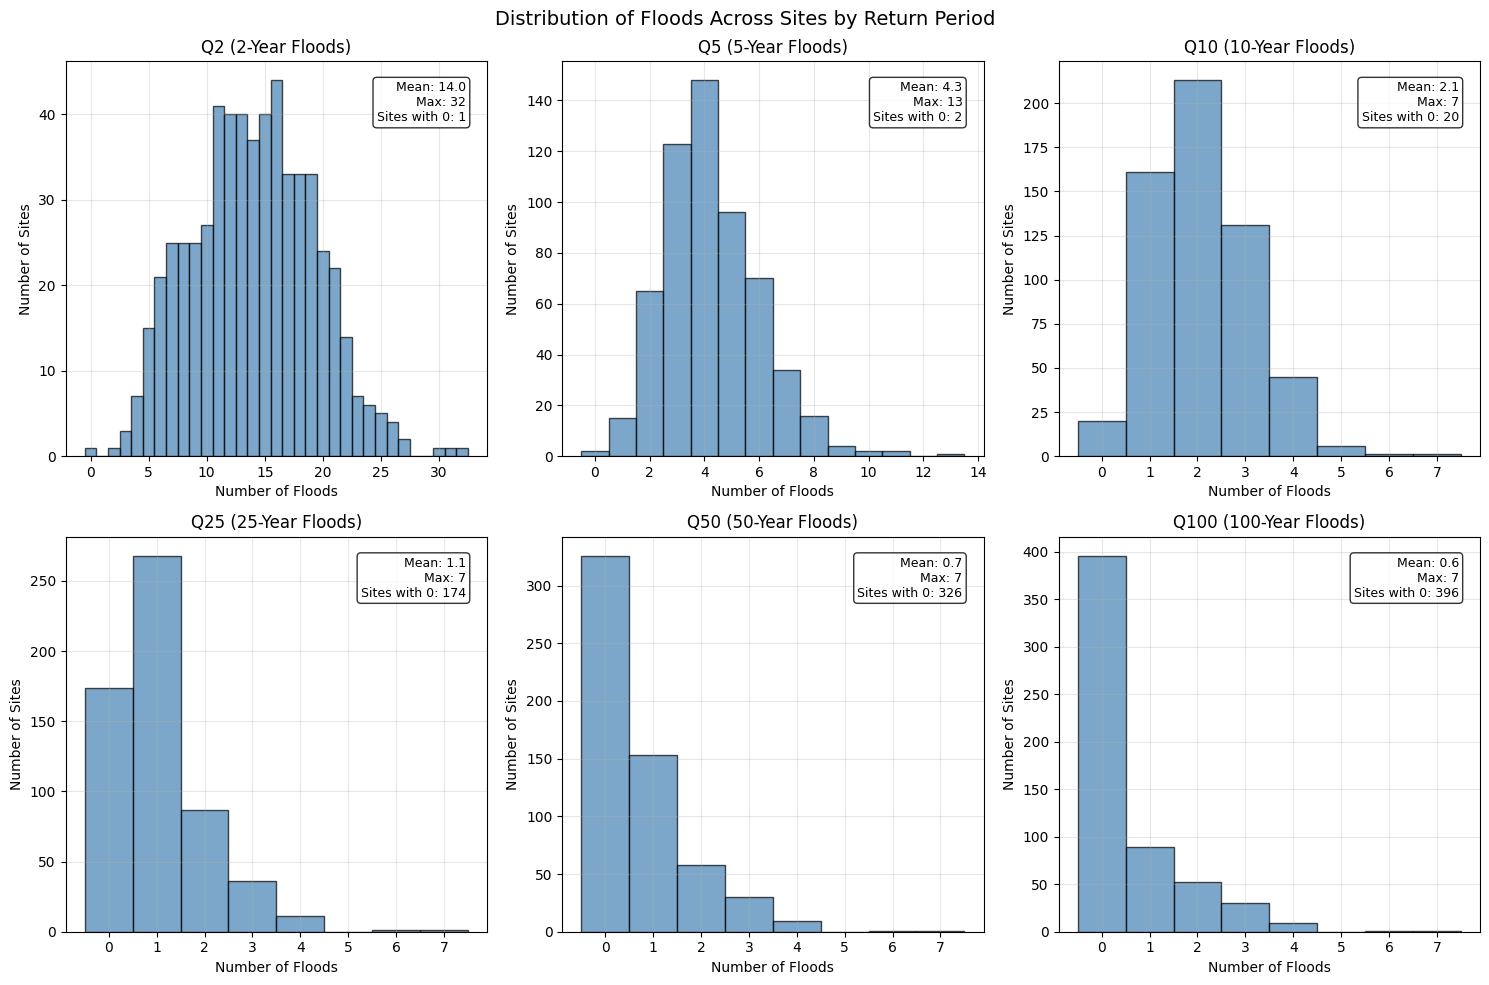

In [21]:
# Plotting the historgrams of flood event counts for each return period
plot_flood_event_histograms(flood_events_sfd)

In [22]:
plot_gauge_locations(flood_events_sfd, "2-Year Flood Events", "floods_Q2", "Flooding Events (2-Year Floods)")

In [23]:
plot_gauge_locations(flood_events_sfd, "5-Year Flood Events", "floods_Q5", "Flooding Events (5-Year Floods)")

In [24]:
plot_gauge_locations(flood_events_sfd, "10-Year Flood Events", "floods_Q10", "Flooding Events (10-Year Floods)")

In [25]:
# Print values for specific site
site_id = "06933500"
print(f"\nAnnual peaks for site {site_id}:")
site_data = annual_peaks_sfd_filt.filter(pl.col("site_id") == site_id)
print(site_data.head(site_data.shape[0]))


Annual peaks for site 06933500:
shape: (19, 4)
┌──────────┬──────┬────────────────────┬─────────────────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date               │
│ ---      ┆ ---  ┆ ---                ┆ ---                     │
│ str      ┆ i32  ┆ f64                ┆ datetime[μs, UTC]       │
╞══════════╪══════╪════════════════════╪═════════════════════════╡
│ 06933500 ┆ 2008 ┆ 104000.0           ┆ 2008-03-20 00:00:00 UTC │
│ 06933500 ┆ 2009 ┆ 26500.0            ┆ 2009-05-09 00:00:00 UTC │
│ 06933500 ┆ 2010 ┆ 41100.0            ┆ 2009-10-31 00:00:00 UTC │
│ 06933500 ┆ 2011 ┆ 80200.0            ┆ 2011-04-27 00:00:00 UTC │
│ 06933500 ┆ 2012 ┆ 43500.0            ┆ 2012-03-24 00:00:00 UTC │
│ 06933500 ┆ 2013 ┆ 117000.0           ┆ 2013-08-07 00:00:00 UTC │
│ 06933500 ┆ 2014 ┆ 8500.0             ┆ 2013-12-24 00:00:00 UTC │
│ 06933500 ┆ 2015 ┆ 46100.0            ┆ 2015-06-22 00:00:00 UTC │
│ 06933500 ┆ 2016 ┆ 128000.0           ┆ 2015-12-29 00:00:00 UTC │
│ 06933500 ┆ 2

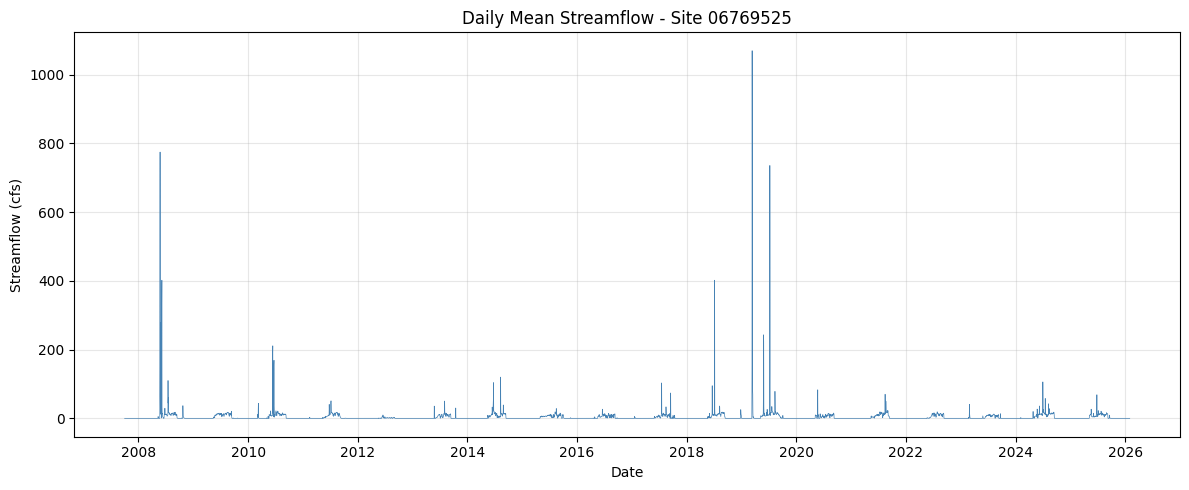

In [26]:
# Select a site_id
site_id = "06769525"

# Filter data for this site
site_data = (
    sfd_df
    .filter(pl.col("site_id") == site_id)
    .filter(pl.col("streamflow_cfs_mean").is_not_null())
    .sort("date")
)

# Extract data for plotting
dates = site_data["date"].to_list()
streamflow = site_data["streamflow_cfs_mean"].to_list()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, streamflow, linewidth=0.5, color="steelblue")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (cfs)")
ax.set_title(f"Daily Mean Streamflow - Site {site_id}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
del sfd_df, artifact, artifact_dir
gc.collect()

24993

In [28]:
# Load the raw streamflow 15min dataset from wandb

artifact = api.artifact("flood-forecasting/raw-streamflow-15min:latest")
artifact_dir = artifact.download()

# Read all year-partitioned parquet files
sf15_df = pl.read_parquet(os.path.join(artifact_dir, "streamflow_15min", "*.parquet"))

wandb: Downloading large artifact 'raw-streamflow-15min:latest', 1467.48MB. 20 files...
wandb:   20 of 20 files downloaded.  
Done. 00:00:00.4 (3908.8MB/s)


In [29]:
print(f"Full dataset: {sf15_df.shape[0]:,} rows x {sf15_df.shape[1]} columns")
print(f"Total sites: {sf15_df['site_id'].n_unique()}")
print(sf15_df.head())
print(f"Date range: {sf15_df['datetime'].min()} to {sf15_df['datetime'].max()}")

size_gb = sf15_df.estimated_size("gb")
print(f"{size_gb:.2f} GB")

Full dataset: 498,403,182 rows x 6 columns
Total sites: 1037
shape: (5, 6)
┌──────────┬────────────────────┬────────────────┬────────────────┬────────────┬───────────────────┐
│ site_id  ┆ datetime           ┆ streamflow_cfs ┆ gage_height_ft ┆ qualifiers ┆ extracted_at      │
│ ---      ┆ ---                ┆ ---            ┆ ---            ┆ ---        ┆ ---               │
│ str      ┆ datetime[μs, UTC]  ┆ f64            ┆ f64            ┆ str        ┆ datetime[μs]      │
╞══════════╪════════════════════╪════════════════╪════════════════╪════════════╪═══════════════════╡
│ 06033000 ┆ 2007-10-01         ┆ 18.0           ┆ null           ┆ A, [91]    ┆ 2026-02-01        │
│          ┆ 06:00:00 UTC       ┆                ┆                ┆            ┆ 09:09:47.101716   │
│ 06033000 ┆ 2007-10-01         ┆ 18.0           ┆ null           ┆ A, [91]    ┆ 2026-02-01        │
│          ┆ 06:15:00 UTC       ┆                ┆                ┆            ┆ 09:09:47.101716   │
│ 06033000 ┆ 200

In [ ]:
site_stats_sf15 = compute_site_stats(sf15_df, "site_id", "streamflow_cfs")

print("Site-level statistics:")
print(site_stats_sf15.shape)

In [ ]:
# Remove sites that are not found in the catchment attributes dataset
site_stats_sf15_filt = site_stats_sf15.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)

# Add latitude and longitude for mapping
site_stats_sf15_filt = site_stats_sf15_filt.join(
    ca_df.select([
        pl.col("site_id"),
        pl.col("LAT_GAGE").alias("latitude"),
        pl.col("LNG_GAGE").alias("longitude")
    ]),
    on="site_id",
    how="left"
)

print(site_stats_sf15_filt.shape)

In [ ]:
# Create annual peaks DataFrame for Log-Pearson Type III Distribution Fitting

annual_peaks_sf15 = calc_annual_peaks(sf15_df, "site_id", "streamflow_cfs_mean", "date")

# Remove sites that are not found in the catchment attributes dataset
annual_peaks_sf15_filt = annual_peaks_sf15.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)
print(f"Annual peaks extracted: {annual_peaks_sf15_filt.shape[0]:,} site-years")
print(annual_peaks_sf15_filt.head())

In [ ]:
# Calculate Log-Pearson Type III quantiles for the annual peaks of the 15 minute streamflow dataset

lp3_results_sf15 = calc_lp3_params(annual_peaks_sf15_filt, "site_id", "peak_discharge_cfs")

print(lp3_results_sf15.head(5))

In [ ]:
# Count flood events exceeding each threshold
flood_events_sf15 = count_flood_events(sf15_df, lp3_results_sf15, "site_id", "streamflow_cfs_mean", "date", 7)

# Add the latitude and longitude for mapping
flood_events_sf15 = flood_events_sf15.join(
    site_stats_filt.select(["site_id", "latitude", "longitude"]),
    on="site_id",
    how="left"
)

print(flood_events_sf15.head(10))

In [ ]:
# Plotting the historgrams of flood event counts for each return period
plot_flood_event_histograms(flood_events_sf15)

In [ ]:
# Combine the two dataframes into one for plotting.
flood_events_combined = pl.concat([flood_events_sfd, flood_events_sf15])

print(f"Combined: {flood_events_combined.shape[0]} rows")
print(flood_events_combined.head(10))

In [ ]:
del sf15_df, artifact, artifact_dir
gc.collect()